# Load modules

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import os
import numpy as np
from shapely.geometry import Polygon

In [3]:
rc = lambda r,c:pl.Config(set_tbl_rows=r,set_tbl_cols=c)

In [4]:
project_name='250328 5deg'
if not os.path.exists('plots/'+project_name):
    os.mkdir('plots/'+project_name)
if not os.path.exists('Processed data/'+project_name):
    os.mkdir('Processed data/'+project_name)
if not os.path.exists('Raw data/'+project_name):
    os.mkdir('Raw data/'+project_name)

# Load data

## Batch files

In [5]:
def read_batch_file(path):
    start = pl.read_csv(path).with_row_index().filter(pl.col('[Header]')=='[Batch Table]')['index'][0]+2
    nrows = int(pl.read_csv(path,
                skip_rows=start,has_header=False,n_rows=1)[0,0].split('\t')[-1])
    return pl.read_csv(path,
                skip_rows=start+1,has_header=True,n_rows=nrows,separator='\t')

In [6]:
b0 = read_batch_file('Processed data/batch files/240428-std curve.txt')
b1 = read_batch_file('Processed data/batch files/250328 4d sol.txt')

batch = pl.concat([b0,b1])
batch

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data File,Background,Background Data File,Level#,Inj. Volume,ISTD Amt.,Sample Amt.,Dil. Factor,System Check,Report Output,Report Format File,User Prog.,Action,Data Comment,AutoPurge,Baseline Check,Option 1,Option 2,Option 3,Option 4,Option 5,Custom Parameters,Auto Tuning,Tuning File,PsiPort Instrument Method File,Summary Type,Summary Report Format File,Option 6,Option 7,Option 8,Option 9,Option 10,System Suitability,Multi Injection,Barcode,Sampler File,Conc. Overrides
str,str,str,str,i64,str,str,str,str,i64,str,i64,f64,str,i64,i64,str,i64,str,str,str,str,i64,i64,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,i64,i64,str,str,str
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""A2""","""buffer""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard:(I)""",null,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.11pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…",0,null,1,3.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""B2""","""0.33pmol ABm1-42""",1,"""1:Standard""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…",0,null,2,9.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DL AQ DP""","""1""","""G7""","""5deg_50uM_4""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_50uM_3_001_…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""Max_test_report.lsr""",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""H7""","""5deg_25uM_3""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_25uM_3_001_…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""Max_test_report.lsr""",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null
"""DL AQ DP""","""1""","""A8""","""5deg_12uM_3""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_12uM_3_001_…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""Max_test_report.lsr""",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null


In [7]:
batch=batch.rename({'Data File':'Data Filename'})

## UV

In [8]:
summary205 = pl.read_csv('Processed data/'+project_name+'/All 205nm reprocessed 260120.txt',
                         skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summary205

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
1,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.395,1872.0,0.079,1227.0,0.11,72.1,"""*""",4.362,4.445,0.03,29.01,1.099
2,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.397,2086.0,0.088,1277.0,0.11,79.8,"""*""",4.347,4.435,0.04,24.76,1.176
3,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.412,9363.0,0.375,4412.0,0.33,113.6,"""*""",4.357,4.545,0.04,93.19,1.737
4,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.407,9840.0,0.394,4726.0,0.33,119.3,"""*""",4.33,4.488,0.04,112.1,1.024
5,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.41,26119.0,1.036,13193.0,1.0,103.6,"""*""",4.34,4.492,0.04,275.81,0.964
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21,"""250328 4d sol_5deg_25uM_2_001_…","""Unknown""","""5deg_25uM_2""","""E7""",4.465,11250.0,0.449,4403.0,null,null,null,4.2,4.538,0.05,88.07,0.818
22,"""250328 4d sol_5deg_25uM_1_001_…","""Unknown""","""5deg_25uM_1""","""B7""",4.458,15750.0,0.627,6109.0,null,null,null,4.218,4.542,0.06,107.08,1.121
23,"""250328 4d sol_5deg_12uM_3_001_…","""Unknown""","""5deg_12uM_3""","""A8""",4.467,47273.0,1.87,19347.0,null,null,null,4.203,4.55,0.04,467.86,0.914


In [9]:
pl.concat([batch,summary205],how='align_full').drop_nulls('Inj. Volume')#.drop_nulls('Area')

Run Mode,Tray Name,Vial#,Sample Name,Sample ID,Sample Type,Analysis Type,Method File,Data Filename,Background,Background Data File,Level#,Inj. Volume,ISTD Amt.,Sample Amt.,Dil. Factor,System Check,Report Output,Report Format File,User Prog.,Action,Data Comment,AutoPurge,Baseline Check,Option 1,Option 2,Option 3,Option 4,Option 5,Custom Parameters,Auto Tuning,Tuning File,PsiPort Instrument Method File,Summary Type,Summary Report Format File,Option 6,Option 7,Option 8,Option 9,Option 10,System Suitability,Multi Injection,Barcode,Sampler File,Conc. Overrides,,Ret. Time,Area,Conc.,Height,Std. Conc.,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
str,str,str,str,i64,str,str,str,str,i64,str,i64,f64,str,i64,i64,str,i64,str,str,str,str,i64,i64,str,str,str,str,str,str,i64,str,str,i64,str,str,str,str,str,str,i64,i64,str,str,str,i64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""DL AQ DP""","""1""","""-1""","""clean""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_clean_001_12.lcd""",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""Max_test_report.lsr""",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""-1""","""none""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_none_001_01.lcd""",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""Max_test_report.lsr""",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""A2""","""buffer""",1,"""2:Control""",null,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",0,null,0,30.0,"""(Level1 Conc.)""",1,1,null,0,"""C:\LabSolutions\System\DEFAULT…",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DL AQ DP""","""1""","""D7""","""5deg_50uM_3""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_50uM_2_001_…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""Max_test_report.lsr""",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""E7""","""5deg_25uM_2""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_25uM_2_001_…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""Max_test_report.lsr""",null,null,null,0,0,null,null,null,null,null,null,0,null,null,0,null,null,null,null,null,null,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""DL AQ DP""","""1""","""F7""","""5deg_12uM_2""",1,"""0:Unknown""",null,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_12uM_2_001_…",0,null,0,10.0,"""(Level1 Conc.)""",1,1,null,0,"""Max_test_report.lsr""",n

In [10]:
batch.columns

['Run Mode',
 'Tray Name',
 'Vial#',
 'Sample Name',
 'Sample ID',
 'Sample Type',
 'Analysis Type',
 'Method File',
 'Data Filename',
 'Background',
 'Background Data File',
 'Level#',
 'Inj. Volume',
 'ISTD Amt.',
 'Sample Amt.',
 'Dil. Factor',
 'System Check',
 'Report Output',
 'Report Format File',
 'User Prog.',
 'Action',
 'Data Comment',
 'AutoPurge',
 'Baseline Check',
 'Option 1',
 'Option 2',
 'Option 3',
 'Option 4',
 'Option 5',
 'Custom Parameters',
 'Auto Tuning',
 'Tuning File',
 'PsiPort Instrument Method File',
 'Summary Type',
 'Summary Report Format File',
 'Option 6',
 'Option 7',
 'Option 8',
 'Option 9',
 'Option 10',
 'System Suitability',
 'Multi Injection',
 'Barcode',
 'Sampler File',
 'Conc. Overrides']

In [11]:
summary205.columns

['',
 'Data Filename',
 'Sample Type',
 'Sample Name',
 'Vial#',
 'Ret. Time',
 'Area',
 'Conc.',
 'Height',
 'Std. Conc.',
 'Accuracy[%]',
 'Cal. Point',
 'Peak Start',
 'Peak End',
 'Quant. Limit(QL)',
 'S/N',
 'Tailing F.']

In [12]:
rc(30,15)

In [13]:
UV = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summary205.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
UV

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_clean_001_12.lcd""","""Control""",null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_none_001_01.lcd""","""Control""",null,null,null,null,null,null,null
"""A2""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",null,null,null,null,null,null,null,null
"""A7""","""5deg_50uM_1""",2.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_50uM_1_001_…","""Unknown""",4.468,8625.0,0.346,4091.0,4.403,4.558,null
"""A7""","""5deg_50uM_2""",8.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_50uM_1_001_…","""Unknown""",4.468,47994.0,1.898,19056.0,4.205,4.55,null
"""A8""","""5deg_12uM_3""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_12uM_3_001_…","""Unknown""",4.467,47273.0,1.87,19347.0,4.203,4.55,null
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.397,2086.0,0.088,1277.0,4.347,4.435,0.11


## MS

In [15]:
summaryMS = pl.read_csv('Processed data/'+project_name+'/All MS reprocessed 260120.txt',
                        skip_rows=2,separator='\t',null_values='-----').drop_nulls('Sample Type')
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,…,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,…,f64,str,f64,f64,f64,f64,str
1,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.411,7114.0,…,61.4,"""*""",4.35,4.567,0.49,1.38,"""1.603"""
2,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.413,7391.0,…,66.5,"""*""",4.35,4.517,0.43,1.7,"""1.458"""
3,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.426,21744.0,…,110.2,"""*""",4.333,4.567,0.96,3.8,"""1.373"""
4,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.423,21860.0,…,110.9,"""*""",4.35,4.567,1.0,3.67,"""1.405"""
5,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.426,60146.0,…,114.1,"""*""",4.35,4.583,1.31,8.72,"""1.506"""
6,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.42,66732.0,…,127.4,"""*""",4.35,4.7,1.43,8.93,"""1.342"""
7,"""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.419,154087.0,…,101.4,"""*""",4.35,4.7,0.67,45.17,"""1.451"""
8,"""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.418,154879.0,…,101.9,"""*""",4.35,4.667,0.65,47.16,"""1.470"""
9,"""240428-std curve_9pmol ABm1-42…","""Standard(Calc.Point)""","""9pmol ABm1-42""","""C2""",4.419,467398.0,…,104.2,"""*""",4.333,4.7,0.96,97.53,"""1.441"""


In [16]:
MS = pl.concat([batch.select(['Vial#','Sample Name','Inj. Volume','Method File','Data Filename'])
,summaryMS.select(['Data Filename','Sample Type', 'Sample Name', 'Vial#',
                    'Ret. Time', 'Area', 'Conc.', 'Height','Peak Start',
 'Peak End','Std. Conc.'])]
           ,how='align_full')#.filter(pl.col('Sample Name').str.contains('pmol'))
#.drop_nulls('Inj. Volume')#.drop_nulls('Area')
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_clean_001_12.lcd""","""Control""",4.283,533.0,-0.066,72.0,4.25,4.517,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_none_001_01.lcd""","""Control""",4.6,322.0,-0.07,56.0,4.567,4.7,null
"""A2""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",null,null,null,null,null,null,null,null
"""A7""","""5deg_50uM_1""",2.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_50uM_1_001_…","""Unknown""",4.483,17497.0,0.278,5096.0,4.367,4.7,null
"""A7""","""5deg_50uM_2""",8.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_50uM_1_001_…","""Unknown""",4.484,72813.0,1.397,21957.0,4.417,5.883,null
"""A8""","""5deg_12uM_3""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_12uM_3_001_…","""Unknown""",4.482,91819.0,1.781,27238.0,4.333,4.783,null
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.413,7391.0,0.073,2228.0,4.35,4.517,0.11


## Chromatograms

In [17]:
path='Raw data/'+project_name+'/all chromatograms/'
list_of_UV_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_UV_chrom.append(name)
list_of_UV_chrom.sort(reverse=True)

In [18]:
data_UV = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [19]:
pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

Time (min),Abs (µAu)
f64,i64
0.0,-1313
0.00167,-1313
0.00333,-1316
0.005,-1319
0.00667,-1322
0.00833,-1326
0.01,-1330
0.01167,-2
0.01333,-7


In [20]:
data_MS = {}
for name in list_of_UV_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [21]:
path='Raw data/240428 std curve/chromatograms/'
list_of_std_chrom=[]
for root, dirs, files in os.walk(path):
    for name in files:
        if '.txt' in name:
            list_of_std_chrom.append(name)
list_of_std_chrom.sort(reverse=True)

In [22]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	205nm')['index'][0]+2
        end_line_205 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[LC Chromatogram(Detector A-Ch2)]')['index'][0]-1

        start_line_280 = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='Wavelength(nm)	280nm')['index'][0]+2
        
        data_UV[name+'_205nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_205,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)
        data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

In [23]:
for name in list_of_std_chrom:
    if 'checkpoint' not in name:
        start_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='m/z	1-2MS(E+) TIC')['index'][0]+6
        end_line_MS = pl.read_csv(path+name).with_row_index().filter(pl.col('[Header]')=='[Peak Table(Detector A-Ch1)]')['index'][0]-1

        
        data_MS[name+'_MS-TIC'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_MS,n_rows=end_line_MS-start_line_MS,new_columns=['Time (min)','Absolute Intensity','Relative Intensity'],ignore_errors=True,truncate_ragged_lines=True)
       # data_UV[name+'_280nm'] = pl.read_csv(path+name,separator='\t', skip_rows=start_line_280,n_rows=end_line_205-start_line_205,new_columns=['Time (min)','Abs (µAu)'],ignore_errors=True)

# Plot integrations & Calculate areas

## UV

### Standard curve

In [24]:
stds = UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.397,2086.0,0.088,1277.0,4.347,4.435,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.395,1872.0,0.079,1227.0,4.362,4.445,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.407,9840.0,0.394,4726.0,4.33,4.488,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.412,9363.0,0.375,4412.0,4.357,4.545,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.405,26554.0,1.053,13510.0,4.343,4.49,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.41,26119.0,1.036,13193.0,4.34,4.492,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.4,680512.0,26.845,304193.0,4.095,4.607,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.4,672593.0,26.533,289481.0,4.137,4.605,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""",4.4,82947.0,3.277,33894.0,4.135,4.567,3.0


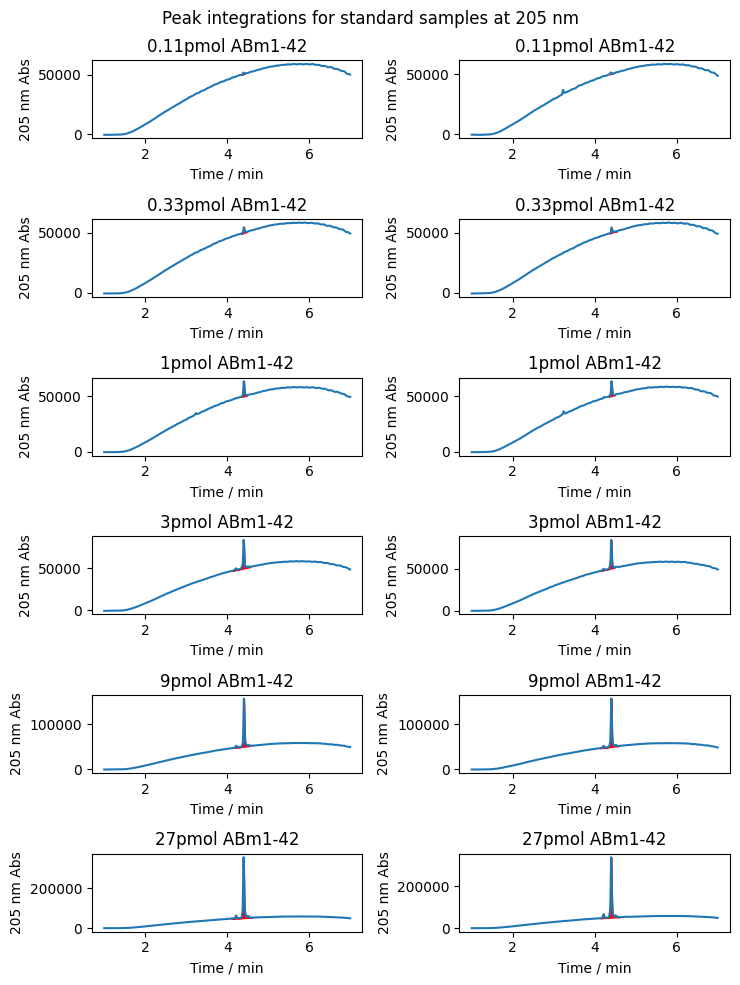

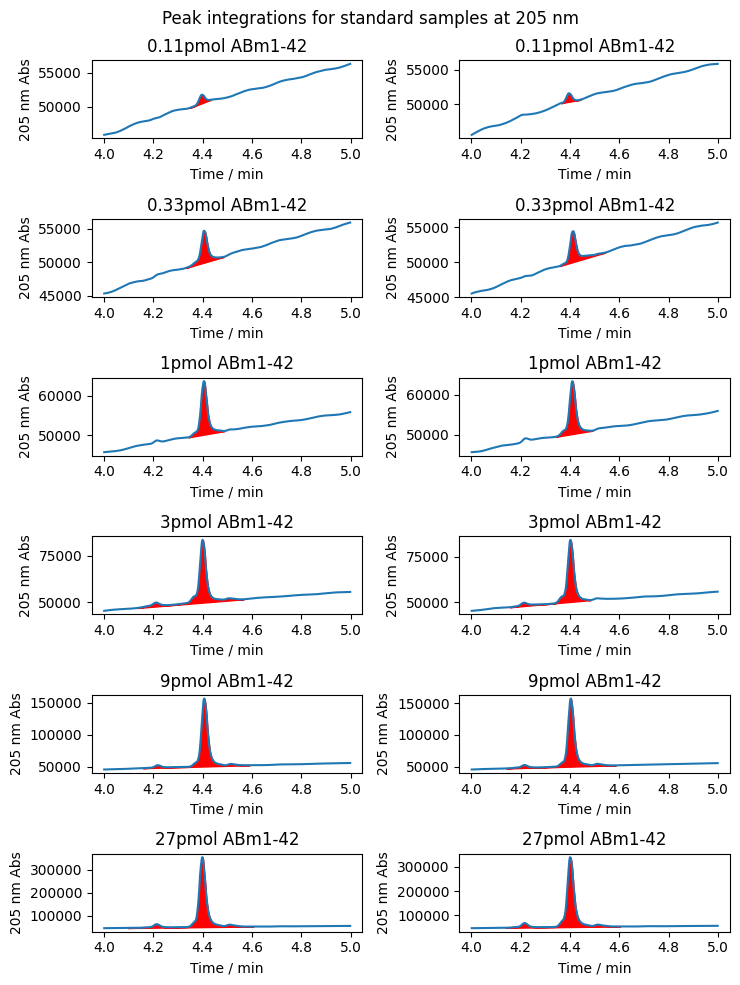

In [25]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=UV.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for standard samples at 205 nm')
    plt.tight_layout()
    #plt.savefig('plots/260105 seeded temp sol/205nm integrations for samples at'+str(temp)+'degrees-original ints.pdf')

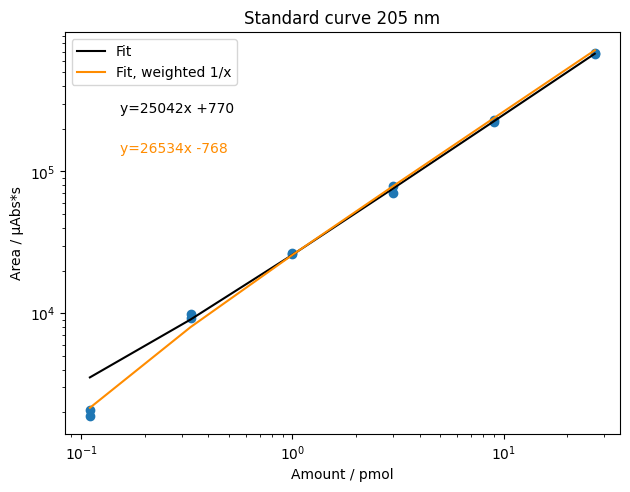

In [26]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x +'+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x '+str(round(fit_w[0])),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / µAbs*s')
plt.tight_layout()
plt.title('Standard curve 205 nm')
std_curve_eq = fit_w

### Samples

In [27]:
UV.with_columns(
    pl.col('Conc.')/pl.col('Inj. Volume')
).sort(by='Sample Name')

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.397,2086.0,0.029333,1277.0,4.347,4.435,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.395,1872.0,0.026333,1227.0,4.362,4.445,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.407,9840.0,0.043778,4726.0,4.33,4.488,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.412,9363.0,0.041667,4412.0,4.357,4.545,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.405,26554.0,0.039,13510.0,4.343,4.49,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.41,26119.0,0.03837,13193.0,4.34,4.492,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.4,680512.0,0.994259,304193.0,4.095,4.607,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.4,672593.0,0.982704,289481.0,4.137,4.605,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""",4.4,82947.0,1.092333,33894.0,4.135,4.567,3.0


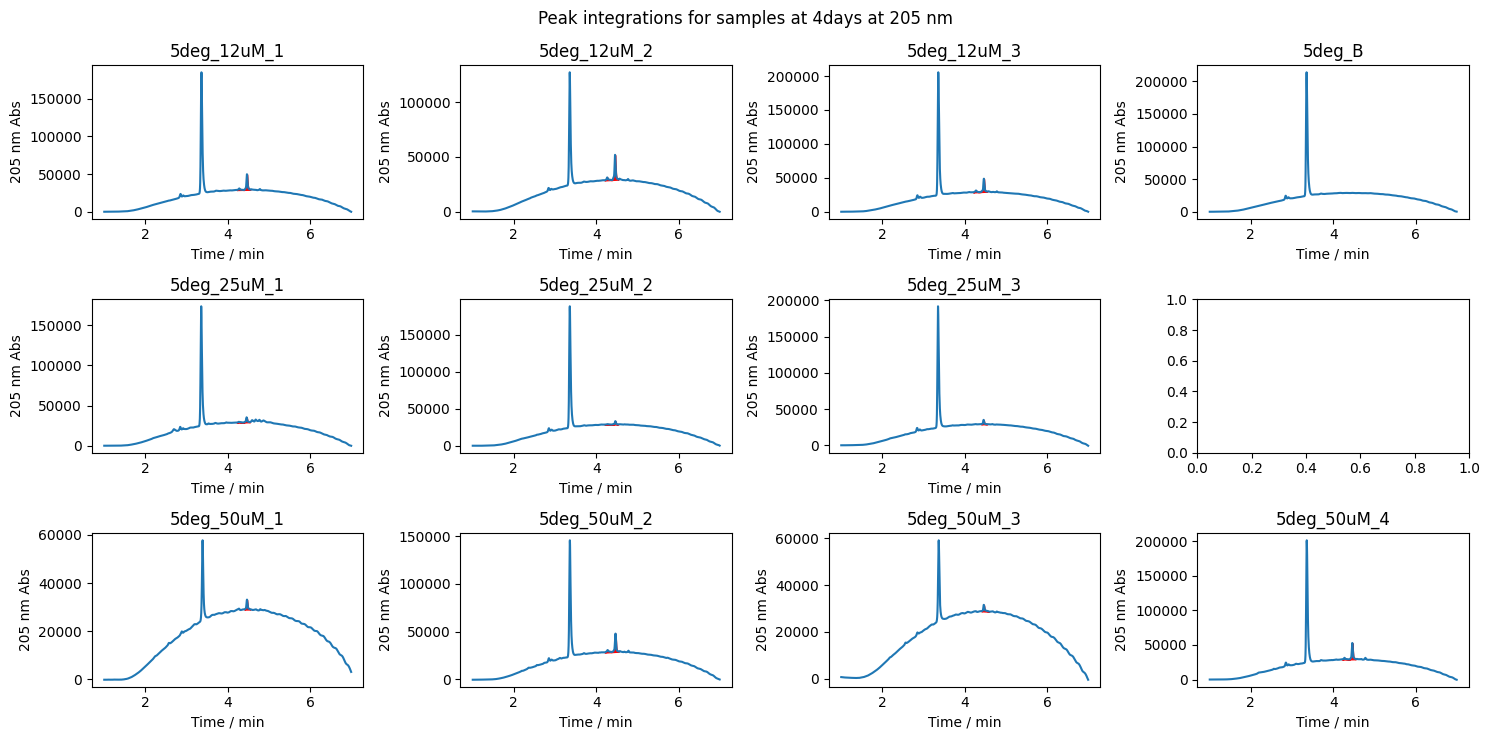

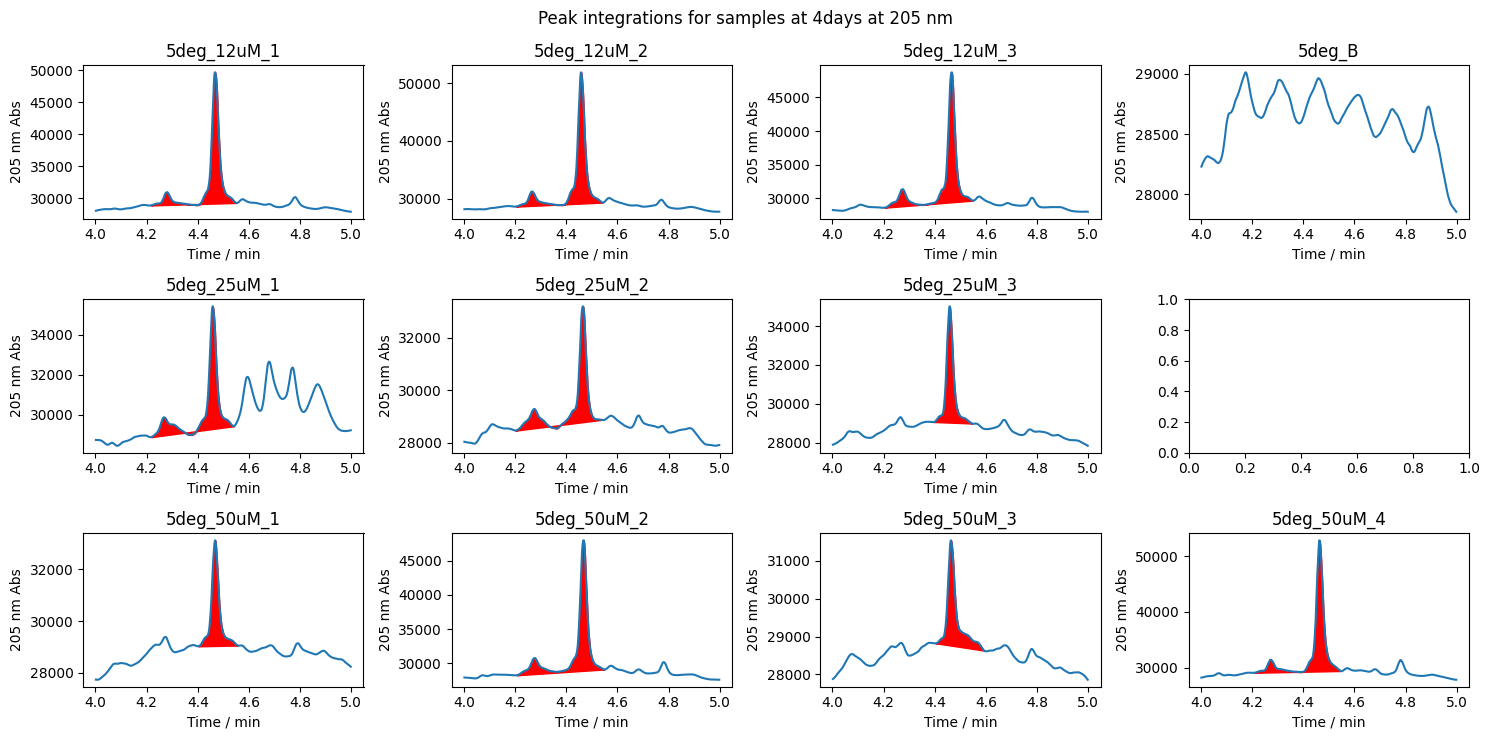

In [28]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
conc_to_row = {'12':0,
               '25':1,
               '50':2}

for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    #for time in ['65h','5days']:

    fig, axs = plt.subplots(3,4,figsize=(15,7.5),sharey=False)
    t_df = UV.filter(pl.col('Sample Type')=="Unknown"
     )
    
    for n,name in enumerate(t_df['Data Filename']):
        if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            peak_start = float(UV.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(UV.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            i=conc_to_row[(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0].split('_')[1][0]+
               t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0].split('_')[1][1])]
            j=int(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][-1])-1
          
            axs[i,j].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            poly_collect = axs[i,j].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Abs (µAu)'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            names.append(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            inj_vols.append(UV.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
            axs[i,j].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[i,j].set_xlabel('Time / min')
            axs[i,j].set_ylabel('205 nm Abs')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_205nm'
            df=data_UV[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            i=0
            j=3
            axs[i,j].plot(df['Time (min)'],
                     df['Abs (µAu)'])
            axs[i,j].set_title(UV.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[i,j].set_xlabel('Time / min')
            axs[i,j].set_ylabel('205 nm Abs')
    plt.suptitle('Peak integrations for samples at 4days at 205 nm')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/205nm integrations for samples at 4 days at 205 nm-zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')


### Calc. Conc.

In [29]:
amounts_UV= pl.DataFrame({'Sample Name':names,
                           'Area (python)':areas,
                          'Inj. Vol.':inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_UV_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [30]:
amounts_UV

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""5deg_50uM_1""",8629.22976,2.0,0.354165
"""5deg_50uM_2""",47886.106581,8.0,1.833647
"""5deg_12uM_3""",47141.136483,10.0,1.805571
"""5deg_25uM_1""",15824.893656,10.0,0.62535
"""5deg_12uM_1""",47610.697665,10.0,1.823268
"""5deg_50uM_3""",6825.00423,10.0,0.286169
"""5deg_25uM_2""",11296.02576,10.0,0.454669
"""5deg_12uM_2""",54097.792668,10.0,2.067748
"""5deg_50uM_4""",54428.015358,10.0,2.080194


In [31]:
concs_UV=amounts_UV.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_UV


Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""5deg_50uM_1""",8629.22976,2.0,0.354165,177.082595
"""5deg_50uM_2""",47886.106581,8.0,1.833647,229.205906
"""5deg_12uM_3""",47141.136483,10.0,1.805571,180.557141
"""5deg_25uM_1""",15824.893656,10.0,0.62535,62.534967
"""5deg_12uM_1""",47610.697665,10.0,1.823268,182.326786
"""5deg_50uM_3""",6825.00423,10.0,0.286169,28.616897
"""5deg_25uM_2""",11296.02576,10.0,0.454669,45.466928
"""5deg_12uM_2""",54097.792668,10.0,2.067748,206.774835
"""5deg_50uM_4""",54428.015358,10.0,2.080194,208.019353


In [32]:
# corr_factor = (10000/
# concs_UV.filter(pl.col('Sample Name')=="10uM ABm1-42"
#                 )['Conc. (nM)'][0])
# corr_factor

In [33]:
# concs_UV=concs_UV.with_columns(
#     (pl.col('Conc. (nM)')*corr_factor).alias('Corr. Conc. (nM)')
# )

In [34]:
concs_UV.filter(~pl.col('Sample Name').str.contains('buffer')
                        ).filter(pl.col('Sample Name').str.contains('12')
                            )['Conc. (nM)'].to_numpy()

array([180.55714093, 182.3267859 , 206.77483543])

In [35]:
concs_UV.filter(pl.col('Sample Name').str.contains('_B'))
                                    

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64


In [36]:
conc=12
y_t1=concs_UV.filter(pl.col('Sample Name').str.contains(conc)
                                        )['Conc. (nM)']#.to_numpy()
           
y_t1=y_t1.filter(y_t1>0).to_numpy()
y_t1

array([180.55714093, 182.3267859 , 206.77483543])

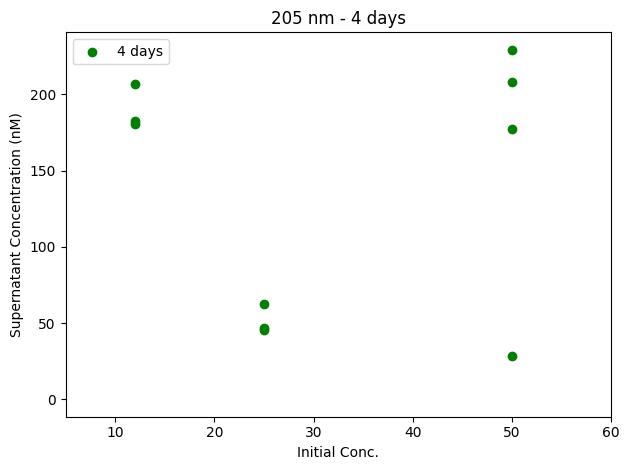

In [37]:
conces=[12,25,50]
t1=[]
#buffer_corr_t2=[]
temps_t1=[]
temps_t2=[]

for conc in conces:
    y_t1=concs_UV.filter(pl.col('Sample Name').str.contains(conc)
                                        )['Conc. (nM)']#.to_numpy()
           
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    t1.append(y_t1)
    #temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([int(conc)]*len(y_t1),y_t1,color='green')
    
    

UV_values = pl.DataFrame({'Temp':[5]*len(t1),
                                           'Conc (nM)':t1,
                                           'Incubation time (days)':[4]*len(t1)
                                          })
plt.scatter(0,0,color='green',label='4 days')
#plt.scatter(0,0,color='blue',label='5 days')
plt.xlim(5,60)
plt.legend()
plt.xlabel('Initial Conc.')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('205 nm - 4 days')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/205nm replicates.pdf')

In [38]:
UV_values.explode(['Conc (nM)']).write_csv('Processed data/'+project_name+'/UV values 260122.csv')

## MS

### Standard curve

In [39]:
stds = MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').with_columns(
     pl.col('Std. Conc.').cast(pl.Float32),
     pl.col('Area').cast(pl.Float32),
     pl.col('Height').cast(pl.Float32)
)
stds

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f32,f64,f32,f64,f64,f32
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.413,7391.0,0.073,2228.0,4.35,4.517,0.11
"""B2""","""0.11pmol ABm1-42""",3.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.411,7114.0,0.068,1993.0,4.35,4.567,0.11
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.423,21860.0,0.366,6440.0,4.35,4.567,0.33
"""B2""","""0.33pmol ABm1-42""",9.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""",4.426,21744.0,0.364,6361.0,4.333,4.567,0.33
"""B2""","""1pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.42,66732.0,1.274,19359.0,4.35,4.7,1.0
"""B2""","""1pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""",4.426,60146.0,1.141,16968.0,4.35,4.583,1.0
"""C2""","""27pmol ABm1-42""",27.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.416,1.308549e6,26.4,369996.0,4.283,4.7,27.0
"""C2""","""27pmol ABm1-42""",27.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_27pmol ABm1-4…","""Standard(Calc.Point)""",4.417,1.288584e6,25.996,378560.0,4.35,4.7,27.0
"""C2""","""3pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""",4.418,154879.0,3.057,44843.0,4.35,4.667,3.0


In [40]:
summaryMS

,Data Filename,Sample Type,Sample Name,Vial#,Ret. Time,Area,…,Accuracy[%],Cal. Point,Peak Start,Peak End,Quant. Limit(QL),S/N,Tailing F.
i64,str,str,str,str,f64,f64,…,f64,str,f64,f64,f64,f64,str
1,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.411,7114.0,…,61.4,"""*""",4.35,4.567,0.49,1.38,"""1.603"""
2,"""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""","""0.11pmol ABm1-42""","""B2""",4.413,7391.0,…,66.5,"""*""",4.35,4.517,0.43,1.7,"""1.458"""
3,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.426,21744.0,…,110.2,"""*""",4.333,4.567,0.96,3.8,"""1.373"""
4,"""240428-std curve_0.33pmol ABm1…","""Standard(Calc.Point)""","""0.33pmol ABm1-42""","""B2""",4.423,21860.0,…,110.9,"""*""",4.35,4.567,1.0,3.67,"""1.405"""
5,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.426,60146.0,…,114.1,"""*""",4.35,4.583,1.31,8.72,"""1.506"""
6,"""240428-std curve_1pmol ABm1-42…","""Standard(Calc.Point)""","""1pmol ABm1-42""","""B2""",4.42,66732.0,…,127.4,"""*""",4.35,4.7,1.43,8.93,"""1.342"""
7,"""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.419,154087.0,…,101.4,"""*""",4.35,4.7,0.67,45.17,"""1.451"""
8,"""240428-std curve_3pmol ABm1-42…","""Standard(Calc.Point)""","""3pmol ABm1-42""","""C2""",4.418,154879.0,…,101.9,"""*""",4.35,4.667,0.65,47.16,"""1.470"""
9,"""240428-std curve_9pmol ABm1-42…","""Standard(Calc.Point)""","""9pmol ABm1-42""","""C2""",4.419,467398.0,…,104.2,"""*""",4.333,4.7,0.96,97.53,"""1.441"""


In [41]:
data_MS['240428-std curve_27pmol ABm1-42_001_13.txt_MS-TIC']

Time (min),Absolute Intensity,Relative Intensity
f64,i64,f64
0.5,4331,1.15
0.517,4415,1.18
0.533,4437,1.18
0.55,4411,1.18
0.567,4409,1.18
0.583,4453,1.19
0.6,4596,1.23
0.617,4769,1.27
0.633,4744,1.27


In [42]:
MS

Vial#,Sample Name,Inj. Volume,Method File,Data Filename,Sample Type,Ret. Time,Area,Conc.,Height,Peak Start,Peak End,Std. Conc.
str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""-1""","""clean""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_clean_001_12.lcd""","""Control""",4.283,533.0,-0.066,72.0,4.25,4.517,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_01.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_none_001_15.l…",null,null,null,null,null,null,null,null
"""-1""","""none""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_none_001_01.lcd""","""Control""",4.6,322.0,-0.07,56.0,4.567,4.7,null
"""A2""","""buffer""",30.0,"""C:\LabSolutions\Data\Max\BioSh…","""240428-std curve_buffer_001_02…",null,null,null,null,null,null,null,null
"""A7""","""5deg_50uM_1""",2.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_50uM_1_001_…","""Unknown""",4.483,17497.0,0.278,5096.0,4.367,4.7,null
"""A7""","""5deg_50uM_2""",8.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_50uM_1_001_…","""Unknown""",4.484,72813.0,1.397,21957.0,4.417,5.883,null
"""A8""","""5deg_12uM_3""",10.0,"""C:\LabSolutions\Data\Max\BioSh…","""250328 4d sol_5deg_12uM_3_001_…","""Unknown""",4.482,91819.0,1.781,27238.0,4.333,4.783,null
"""B2""","""0.11pmol ABm1-42""",3.0,"""BioShell_AB(M1-42)_MS_QC+Quant…","""240428-std curve_0.11pmol ABm1…","""Standard(Calc.Point)""",4.413,7391.0,0.073,2228.0,4.35,4.517,0.11


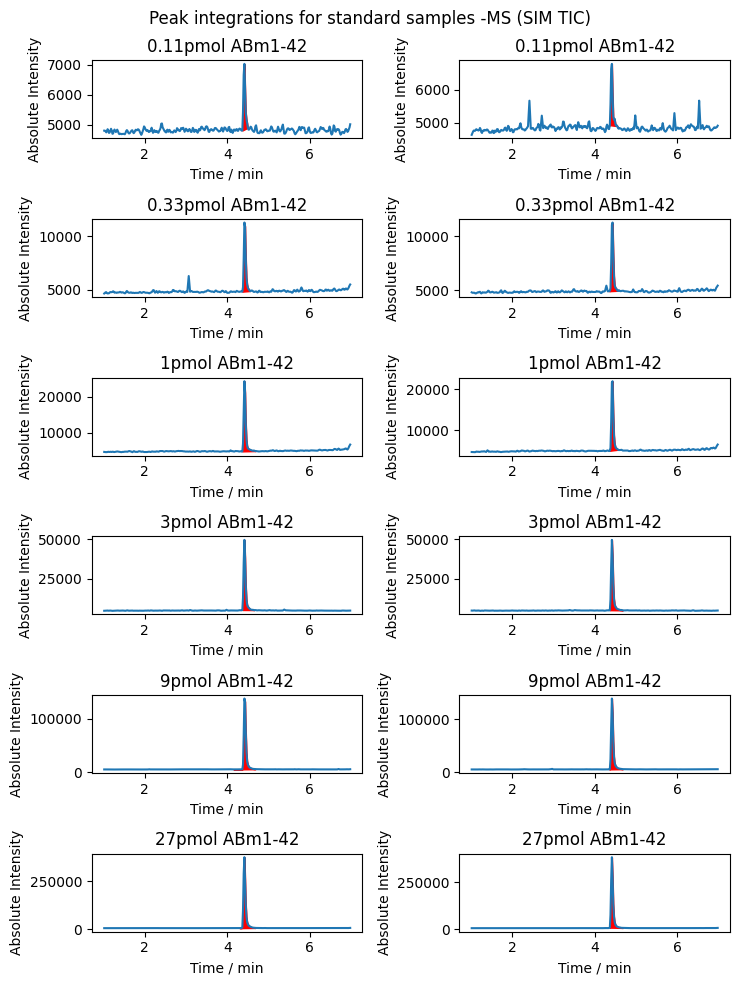

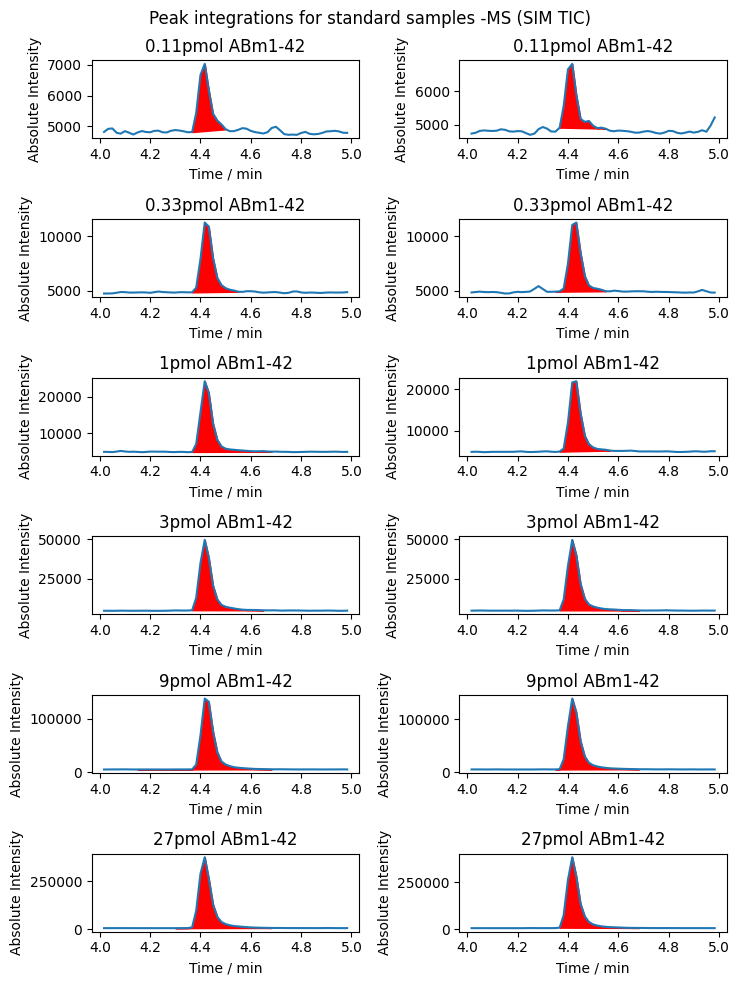

In [43]:

pos = [(i,j) for i in range(6) for j in range(2)]
#methods = ['UV','MS']
for zoom in [(1,7),(4,5)]:
    std_names=[]
    std_areas=[]
    fig, axs = plt.subplots(6,2,figsize=(7.5,10),sharey=False)
    #for n,df in enumerat([UV,MS]):
    summary=MS.filter(pl.col('Sample Type')=='Standard(Calc.Point)').sort(by='Std. Conc.')
    for i,name in enumerate(summary['Data Filename']):
        if summary.filter(pl.col('Data Filename')==name)['Peak Start'][0] != '-----':
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(summary.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(summary.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[pos[i]].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            std_areas.append(area*60) # to get it in A.U.*s as in Labsolutions?
            std_names.append(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
           
            axs[pos[i]].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            axs[pos[i]].set_title(summary.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[pos[i]].set_xlabel('Time / min')
            axs[pos[i]].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for standard samples -MS (SIM TIC)')
    plt.tight_layout()
    #plt.savefig('plots/260105 seeded temp sol/205nm integrations for samples at'+str(temp)+'degrees-original ints.pdf')

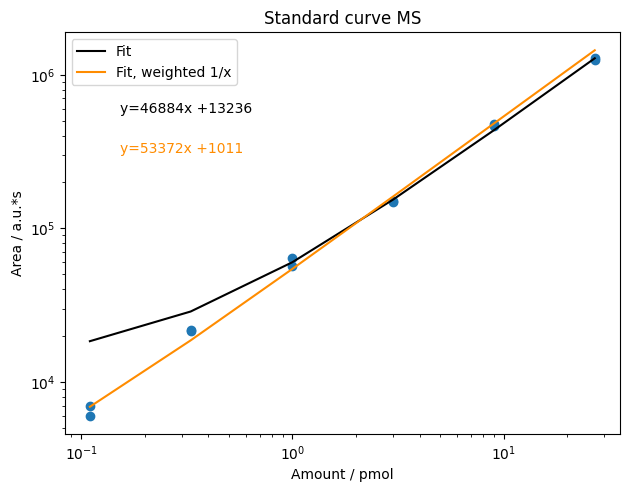

In [44]:

df= stds.sort(by='Std. Conc.')
std_curve = pl.DataFrame({
                'pmol':df['Std. Conc.'],
                'area':std_areas})
fit = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1).convert().coef
fit_w = np.polynomial.Polynomial.fit(std_curve['pmol'],std_curve['area'],deg=1,w=1/std_curve['pmol']).convert().coef
plt.scatter(std_curve['pmol'],std_curve['area'])
plt.plot(std_curve['pmol'],std_curve['pmol']*fit[1]+fit[0],label='Fit',c='black')
plt.plot(std_curve['pmol'],std_curve['pmol']*fit_w[1]+fit_w[0],label='Fit, weighted 1/x',c='darkorange')
plt.annotate('y='+str(round(fit[1]))+'x +'+str(round(fit[0])),
         (.1,.8),xycoords='axes fraction')
plt.annotate('y='+str(round(fit_w[1]))+'x +'+str(round(fit_w[0])),
         (.1,.7),xycoords='axes fraction',c='darkorange')
plt.loglog()
plt.legend()
plt.xlabel('Amount / pmol')
plt.ylabel('Area / a.u.*s')
plt.tight_layout()
plt.title('Standard curve MS')
std_curve_eq = fit_w

### Samples

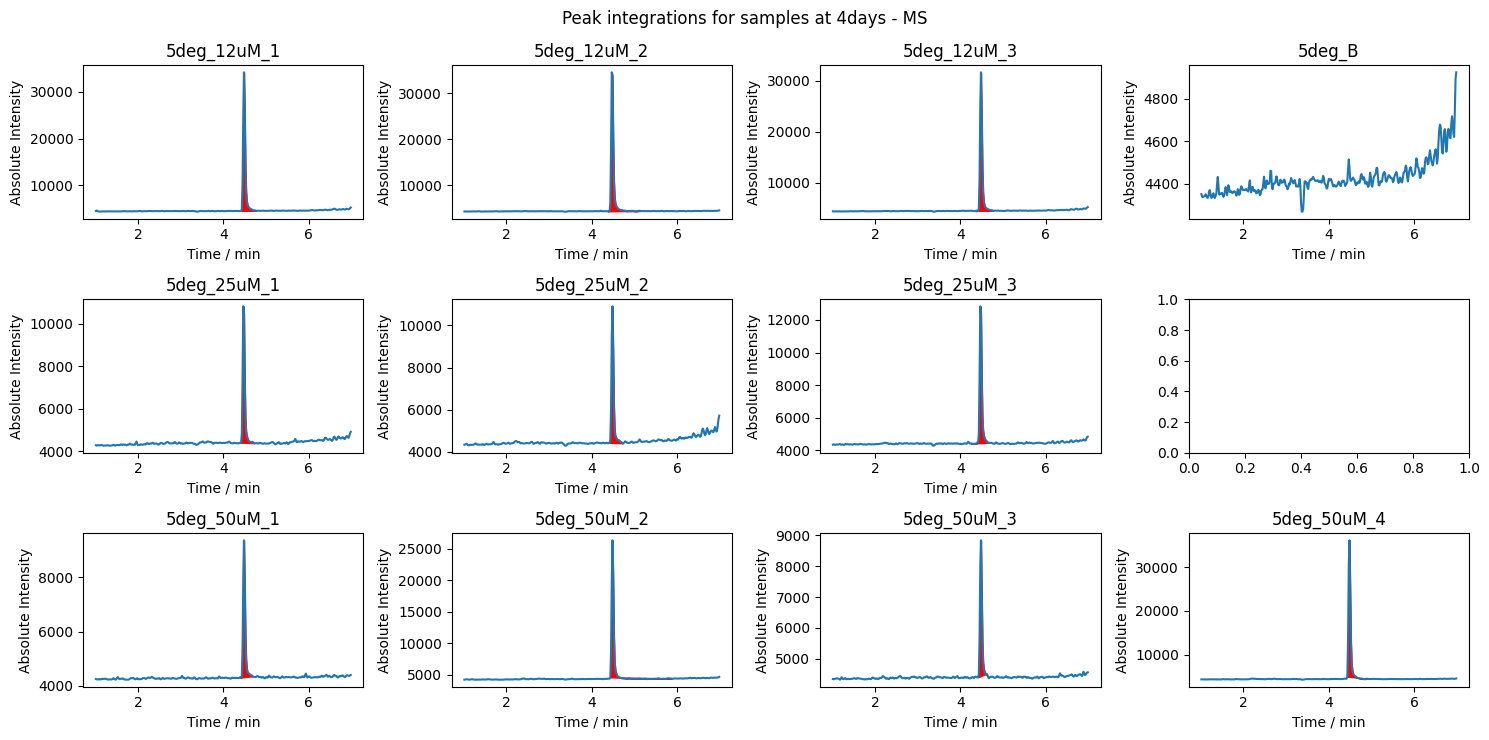

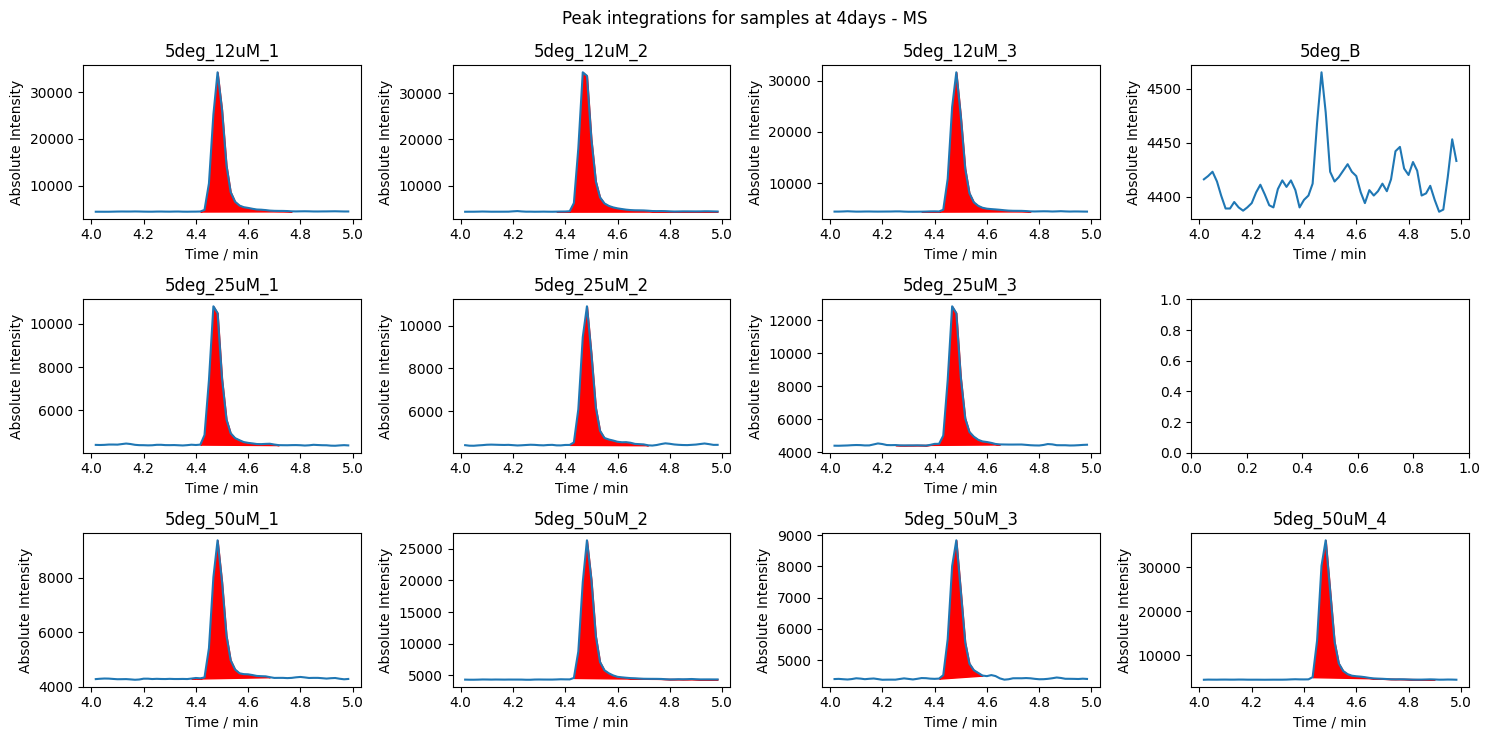

In [45]:
# time='65h'
# t1 = UV.filter(pl.col('Sample Type')=="Unknown"
#          ).filter(pl.col('Data Filename').str.contains(time))
conc_to_row = {'12':0,
               '25':1,
               '50':2}

for zoom in [(1,7),(4,5)]:
    
    names=[]
    areas=[]
    inj_vols=[]

    #for temp in ['18','23','30','40','70']:
    #for time in ['65h','5days']:

    fig, axs = plt.subplots(3,4,figsize=(15,7.5),sharey=False)
    t_df = MS.filter(pl.col('Sample Type')=="Unknown"
     )
    
    for n,name in enumerate(t_df['Data Filename']):
        if t_df.filter(pl.col('Data Filename')==name)['Peak Start'][0]:
    
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            peak_start = float(MS.filter(pl.col('Data Filename')==name)['Peak Start'][0])
            peak_end = float(MS.filter(pl.col('Data Filename')==name)['Peak End'][0])
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            x=np.array([df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][0],
                   df.filter(pl.col('Time (min)')>peak_start
                     ).filter(pl.col('Time (min)')<peak_end)['Time (min)'][-1]])
            y=[df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][0],
               df.filter(pl.col('Time (min)')>peak_start
                 ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'][-1]]
            slope, intercept = np.polyfit(x, y, 1)
            baseline = int(slope) * df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'] + intercept
            i=conc_to_row[(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0].split('_')[1][0]+
               t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0].split('_')[1][1])]
            j=int(t_df.filter(pl.col('Data Filename')==name)['Sample Name'][0][-1])-1
            axs[i,j].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            poly_collect = axs[i,j].fill_between(df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Time (min)'],
                             df.filter(pl.col('Time (min)')>peak_start
                                         ).filter(pl.col('Time (min)')<peak_end)['Absolute Intensity'],
                            baseline,color='red')
            paths = poly_collect.get_paths()
            area = 0
            for path in paths:
                poly = Polygon(path.vertices)
                area += poly.area
            areas.append(area*60) # to get it in µAbs*s as in Labsolutions
            names.append(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            inj_vols.append(MS.filter(pl.col('Data Filename')==name)['Inj. Volume'][0])
            axs[i,j].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[i,j].set_xlabel('Time / min')
            axs[i,j].set_ylabel('Absolute Intensity')
        else:
            chrom_name = name.split('.lcd')[0]+'.txt'+'_MS-TIC'
            df=data_MS[chrom_name].filter(pl.col('Time (min)')>zoom[0]
                                         ).filter(pl.col('Time (min)')<zoom[1])
            i=0
            j=3
            axs[i,j].plot(df['Time (min)'],
                     df['Absolute Intensity'])
            axs[i,j].set_title(MS.filter(pl.col('Data Filename')==name)['Sample Name'][0])
            axs[i,j].set_xlabel('Time / min')
            axs[i,j].set_ylabel('Absolute Intensity')
    plt.suptitle('Peak integrations for samples at 4days - MS')
    plt.tight_layout()
    plt.savefig('plots/'+project_name+'/MS integrations for samples at 4days -MS-zoomed between '+str(zoom[0])+' and '+str(zoom[1])+'.pdf')


### Calc. Conc.

In [46]:
amounts_MS= pl.DataFrame({'Sample Name':names,
                           'Area (python)':areas,
                          'Inj. Vol.':inj_vols
                          # 'Amount (pmol)':[(areas-fit_w[0])/fit_w[1]]+[(control_areas-fit_w[0])/fit_w[1]], #amount (pmol) calculated from area and standard curve, divided by injection volume of 30 µl, times a 1000 to get nM
                            }).with_columns(
    ((pl.col('Area (python)')-fit_w[0])/fit_w[1]).alias('Amount (pmol)')
)
# conces_MS_man_int.with_columns(
#     (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
# )

In [47]:
amounts_MS

Sample Name,Area (python),Inj. Vol.,Amount (pmol)
str,f64,f64,f64
"""5deg_50uM_1""",16602.918,2.0,0.292139
"""5deg_50uM_2""",68458.764,8.0,1.263732
"""5deg_12uM_3""",91409.42391,10.0,1.693745
"""5deg_25uM_1""",21754.416,10.0,0.388659
"""5deg_12uM_1""",99810.462,10.0,1.851151
"""5deg_50uM_3""",13854.99,10.0,0.240652
"""5deg_25uM_2""",21444.756,10.0,0.382857
"""5deg_12uM_2""",107835.69,10.0,2.001515
"""5deg_50uM_4""",98522.41092,10.0,1.827017


In [48]:
concs_MS=amounts_MS.with_columns(
    (pl.col('Amount (pmol)')/pl.col('Inj. Vol.')*1000).alias('Conc. (nM)')
)
concs_MS#.filter(pl.col('Sample Name').str.contains('40')
                             #   )

Sample Name,Area (python),Inj. Vol.,Amount (pmol),Conc. (nM)
str,f64,f64,f64,f64
"""5deg_50uM_1""",16602.918,2.0,0.292139,146.069311
"""5deg_50uM_2""",68458.764,8.0,1.263732,157.9665
"""5deg_12uM_3""",91409.42391,10.0,1.693745,169.374541
"""5deg_25uM_1""",21754.416,10.0,0.388659,38.86593
"""5deg_12uM_1""",99810.462,10.0,1.851151,185.115087
"""5deg_50uM_3""",13854.99,10.0,0.240652,24.065226
"""5deg_25uM_2""",21444.756,10.0,0.382857,38.285738
"""5deg_12uM_2""",107835.69,10.0,2.001515,200.151498
"""5deg_50uM_4""",98522.41092,10.0,1.827017,182.701739


In [49]:
# corr_factor = (10000/
# concs_MS.filter(pl.col('Sample Name')=="10uM ABm1-42"
#                 )['Conc. (nM)'][0])
# corr_factor

In [50]:
# concs_MS=concs_MS.with_columns(
#     (pl.col('Conc. (nM)')*corr_factor).alias('Conc. (nM)')
# )

In [51]:
# concs_MS.filter(~pl.col('Sample Name').str.contains('buffer')
#                         ).filter(pl.col('Sample Name').str.contains('70')
#                             ).filter(pl.col('Sample Name').str.contains('65h'))['Conc. (nM)'].to_numpy()

In [52]:
# concs_MS.filter(pl.col('Sample Name').str.contains('buffer'))
                                    

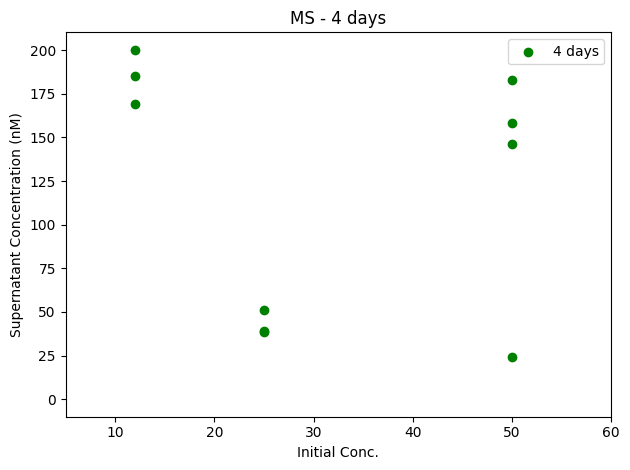

In [53]:
conces=[12,25,50]
t1=[]
#buffer_corr_t2=[]
temps_t1=[]
temps_t2=[]

for conc in conces:
    y_t1=concs_MS.filter(pl.col('Sample Name').str.contains(conc)
                                        )['Conc. (nM)']#.to_numpy()
           
    y_t1=y_t1.filter(y_t1>0).to_numpy()
    t1.append(y_t1)
    #temps_t1.append([int(temp)]*len(y_t1))
    
    plt.scatter([int(conc)]*len(y_t1),y_t1,color='green')
    
    

values = pl.DataFrame({'Temp':[5]*len(t1),
                                           'Conc (nM)':t1,
                                           'Incubation time (days)':[4]*len(t1)
                                          })
plt.scatter(0,0,color='green',label='4 days')
#plt.scatter(0,0,color='blue',label='5 days')
plt.xlim(5,60)
plt.legend()
plt.xlabel('Initial Conc.')
plt.ylabel('Supernatant Concentration (nM)')
plt.title('MS - 4 days')
plt.tight_layout()
plt.savefig('plots/'+project_name+'/MS replicates.pdf')

In [54]:
values.explode(['Conc (nM)']).write_csv('Processed data/'+project_name+'/MS values 260122.csv')